# 🚶 Pedestrian Action Classifier — LSTM

Classifies each pedestrian track into one of **3 action classes** using bounding-box motion sequences:

| Class | Label ID | Description |
|---|---|---|
| **Walking** | 0 | Moving along the pavement / sidewalk |
| **Standing** | 1 | Stationary or near-stationary |
| **Crossing** | 2 | Crossing the road (lateral movement) |

---
**Input features per frame** (8 features):
`cx, cy, w, h, dx, dy, speed, aspect_ratio`

**Model:** Bidirectional LSTM → Linear head  
**Output:** Saved as `lstm_action_classifier.pth` → used by the video pipeline

## Step 1 — Install & Import

In [1]:
!pip install torch torchvision --quiet

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, glob, warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f' Device: {DEVICE}')

 Device: cpu


## Step 2 — Mount Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print(' Drive mounted')

Mounted at /content/drive
 Drive mounted


## Step 3 — Configuration

In [8]:
import glob
import os
import pandas as pd

# Base directory that contains V1, V2, V3, V4...
CSV_BASE_DIR = '/content/drive/MyDrive/GIU.Master/Version 3/csv'

# Collect all frameslabels.csv from all version folders
WALK_STAND_CSVS = glob.glob(
    os.path.join(CSV_BASE_DIR, 'V*/frameslabels.csv')
)

print("Found CSVs:")
for p in WALK_STAND_CSVS:
    print(p)

# ── MERGE THEM ─────────────────────────────────────────

dfs = []

for path in WALK_STAND_CSVS:
    df = pd.read_csv(path)

    # add version column automatically (V1, V2, ...)
    version_name = os.path.basename(os.path.dirname(path))
    df['source_version'] = version_name

    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)

print("Total rows after merge:", len(merged_df))

# ── SAVE MERGED CSV ────────────────────────────────────

OUTPUT_PATH = os.path.join(CSV_BASE_DIR, 'merged_frameslabels.csv')
merged_df.to_csv(OUTPUT_PATH, index=False)

print(f"Merged CSV saved to: {OUTPUT_PATH}")

# Crossing annotations stay the same
CROSSING_CSV_DIR = CSV_BASE_DIR


Found CSVs:
/content/drive/MyDrive/GIU.Master/Version 3/csv/V1/frameslabels.csv
/content/drive/MyDrive/GIU.Master/Version 3/csv/V2/frameslabels.csv
/content/drive/MyDrive/GIU.Master/Version 3/csv/V3/frameslabels.csv
/content/drive/MyDrive/GIU.Master/Version 3/csv/V4/frameslabels.csv
Total rows after merge: 16907
Merged CSV saved to: /content/drive/MyDrive/GIU.Master/Version 3/csv/merged_frameslabels.csv


In [6]:
# ── EDIT THESE PATHS ───────────────────────────────────────────────


# Where to save the trained LSTM model
OUTPUT_MODEL = '/content/drive/MyDrive/GIU.Master/lstm_action_classifier.pth'

# ── Sequence config ────────────────────────────────────────────────
SEQ_LEN    = 20    # frames of history per sample
STRIDE     = 5     # sliding window stride
BATCH_SIZE = 64
EPOCHS     = 40
LR         = 1e-3

# Class definitions
CLASS_NAMES = ['Walking', 'Standing', 'Crossing']
N_CLASSES   = 3
N_FEATURES  = 8    # cx, cy, w, h, dx, dy, speed, aspect_ratio

print(' Config ready')
print(f'   Sequence length : {SEQ_LEN} frames')
print(f'   Classes         : {CLASS_NAMES}')

 Config ready
   Sequence length : 20 frames
   Classes         : ['Walking', 'Standing', 'Crossing']


## Step 4 — Load & Engineer Features

From each bbox row we compute:
- `cx, cy` — centroid position (normalised by frame size)
- `w, h` — bbox dimensions (normalised)
- `dx, dy` — frame-to-frame centroid displacement
- `speed` — Euclidean speed `√(dx²+dy²)`
- `aspect_ratio` — `w/h`

In [9]:
def engineer_features(df: pd.DataFrame,
                      frame_w: int = 1920,
                      frame_h: int = 1080) -> pd.DataFrame:
    """Add motion features to a sorted bbox dataframe."""
    df = df.sort_values(['track_id', 'frame']).copy()
    df['cx'] = ((df['xtl'] + df['xbr']) / 2) / frame_w
    df['cy'] = ((df['ytl'] + df['ybr']) / 2) / frame_h
    df['w']  = (df['xbr'] - df['xtl']) / frame_w
    df['h']  = (df['ybr'] - df['ytl']) / frame_h
    df['dx'] = df.groupby('track_id')['cx'].diff().fillna(0)
    df['dy'] = df.groupby('track_id')['cy'].diff().fillna(0)
    df['speed']        = np.sqrt(df['dx']**2 + df['dy']**2)
    df['aspect_ratio'] = df['w'] / (df['h'] + 1e-6)
    return df


FEAT_COLS = ['cx', 'cy', 'w', 'h', 'dx', 'dy', 'speed', 'aspect_ratio']

# ── Load Walking + Standing ────────────────────────────────────────
df_ws = pd.read_csv('/content/drive/MyDrive/GIU.Master/Version 3/csv/merged_frameslabels.csv')
df_ws.columns = df_ws.columns.str.lower()
print(f'Walk/Stand rows: {len(df_ws)}')
print(f'Labels: {df_ws["label"].value_counts().to_dict()}')

df_ws = engineer_features(df_ws)
# Map to int label
label_map = {'walking': 0, 'standing': 1, 'crossing': 2}
df_ws['label_int'] = df_ws['label'].str.lower().map(label_map)

print(f'\n✅ Walk/Stand features engineered')
print(df_ws[FEAT_COLS + ['label_int']].head(3))

Walk/Stand rows: 16907
Labels: {'Walking': 10965, 'Crossing': 3064, 'Standing': 2878}

✅ Walk/Stand features engineered
             cx        cy         w         h        dx        dy     speed  \
14651  0.993750  1.212963  0.057292  0.287037  0.000000  0.000000  0.000000   
14652  0.996354  1.215741  0.057292  0.287037  0.002604  0.002778  0.003808   
14653  0.998958  1.218519  0.057292  0.287037  0.002604  0.002778  0.003808   

       aspect_ratio  label_int  
14651      0.199596          1  
14652      0.199596          1  
14653      0.199596          1  


## Step 5 — Build Crossing Sequences from Annotation CSVs

> Your `crossing_annotations.csv` files contain per-frame bbox data with a `crossed` label.  
> Tracks labelled **crossed=1** are used as **Crossing** samples.  
> Tracks labelled **crossed=0** near the road are used as additional **Standing/Waiting** samples.

In [11]:
crossing_frames = []

csv_files = glob.glob(os.path.join(CROSSING_CSV_DIR, '**', 'crossing_annotations.csv'), recursive=True)
# Filter out empty ones
csv_files = [p for p in csv_files if os.path.getsize(p) > 100]
print(f'Found {len(csv_files)} annotation CSVs')

for csv_path in csv_files:
    try:
        tmp = pd.read_csv(csv_path)
        tmp.columns = tmp.columns.str.lower()
        # Need: frame, track_id, xtl/ytl/xbr/ybr (or bbox columns), crossed
        required = {'frame', 'track_id', 'crossed'}
        if not required.issubset(set(tmp.columns)):
            print(f'    Skipping {csv_path} — missing columns {required - set(tmp.columns)}')
            continue

        # Check if bbox columns exist
        bbox_cols = {'xtl', 'ytl', 'xbr', 'ybr'}
        if not bbox_cols.issubset(set(tmp.columns)):
            print(f'    Skipping {csv_path} — no bbox columns')
            continue

        tmp['crossed'] = tmp['crossed'].astype(str).str.lower()
        # crossed=1/yes/crossed → Crossing class; crossed=0/no/waited → Standing class
        tmp['label_int'] = tmp['crossed'].map(
            lambda x: 2 if x in ['1', 'yes', 'crossed', 'cross'] else 1
        )
        crossing_frames.append(tmp)
        print(f'   {os.path.basename(os.path.dirname(csv_path))}: {len(tmp)} rows')
    except Exception as e:
        print(f'   {csv_path}: {e}')

if crossing_frames:
    df_cross = pd.concat(crossing_frames, ignore_index=True)
    df_cross = engineer_features(df_cross)
    print(f'\nCrossing CSV total rows: {len(df_cross)}')
    print(f'Class distribution: {dict(df_cross["label_int"].value_counts())}')
else:
    print('\n  No crossing CSVs loaded — model will train on Walking + Standing only')
    print('   Add your crossing-labelled bbox CSV to include the Crossing class.')
    df_cross = pd.DataFrame(columns=df_ws.columns)

Found 6 annotation CSVs
   V1: 1031 rows
   V3: 559 rows
   V4: 1474 rows
   archive: 1474 rows
   V5: 1075 rows
   V6: 144 rows

Crossing CSV total rows: 5757
Class distribution: {2: np.int64(3592), 1: np.int64(2165)}


## Step 6 — Build Sliding Window Sequences

In [12]:
def make_sequences(df: pd.DataFrame,
                   seq_len: int = SEQ_LEN,
                   stride: int  = STRIDE) -> tuple:
    """
    Slide a window of length seq_len over each track.
    Returns X (N, seq_len, n_features) and y (N,) arrays.
    Label = majority class in the window.
    """
    X_list, y_list = [], []

    for tid, group in df.groupby('track_id'):
        group = group.sort_values('frame')
        feats  = group[FEAT_COLS].values.astype(np.float32)
        labels = group['label_int'].values

        if len(feats) < seq_len:
            # Pad with zeros at the beginning
            pad_len = seq_len - len(feats)
            feats  = np.vstack([np.zeros((pad_len, len(FEAT_COLS)), dtype=np.float32), feats])
            labels = np.concatenate([np.full(pad_len, labels[0]), labels])

        for start in range(0, len(feats) - seq_len + 1, stride):
            window = feats[start: start + seq_len]
            # Majority vote label in this window
            win_labels = labels[start: start + seq_len]
            majority   = int(np.bincount(win_labels.astype(int)).argmax())
            X_list.append(window)
            y_list.append(majority)

    return np.array(X_list), np.array(y_list)


# Combine all data
df_all = pd.concat([df_ws, df_cross], ignore_index=True) if len(df_cross) > 0 else df_ws.copy()

X, y = make_sequences(df_all)

print(f'Total sequences : {len(X)}')
print(f'Sequence shape  : {X.shape}   (samples, time_steps, features)')
print(f'Label distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = int((y == i).sum())
    print(f'  {name:10s} ({i}): {count}')

Total sequences : 4338
Sequence shape  : (4338, 20, 8)   (samples, time_steps, features)
Label distribution:
  Walking    (0): 2162
  Standing   (1): 1008
  Crossing   (2): 1168


## Step 7 — Dataset & DataLoader

In [14]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_loader = DataLoader(SequenceDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SequenceDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f'Train samples : {len(X_train)}')
print(f'Val   samples : {len(X_val)}')
print(f' DataLoaders ready')

Train samples : 3470
Val   samples : 868
 DataLoaders ready


## Step 8 — Define Bidirectional LSTM Model

In [16]:
class PedestrianLSTM(nn.Module):
    """
    Bidirectional LSTM for pedestrian action classification.
    Input : (batch, seq_len, n_features)
    Output: (batch, n_classes) logits
    """
    def __init__(self, n_features=N_FEATURES, hidden=128, n_layers=2, n_classes=N_CLASSES, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.norm    = nn.LayerNorm(hidden * 2)   # *2 for bidirectional
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Sequential(
            nn.Linear(hidden * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len, features)
        out, _ = self.lstm(x)          # (batch, seq_len, hidden*2)
        out    = out[:, -1, :]         # take last time step
        out    = self.norm(out)
        out    = self.dropout(out)
        return self.fc(out)            # (batch, n_classes)


model = PedestrianLSTM().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' Model ready   |   Trainable params: {total_params:,}')
print(model)

 Model ready   |   Trainable params: 553,731
PedestrianLSTM(
  (lstm): LSTM(8, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


## Step 9 — Train

In [17]:
# Class weights to handle imbalance (Standing is minority)
class_counts = np.bincount(y_train)
weights      = 1.0 / (class_counts + 1e-6)
weights      = weights[:N_CLASSES]   # only defined classes
# Pad to N_CLASSES if some classes missing in training set
if len(weights) < N_CLASSES:
    weights = np.pad(weights, (0, N_CLASSES - len(weights)), constant_values=1.0)
weights = torch.tensor(weights / weights.sum(), dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    # ── Validate ──────────────────────────────────────────────
    model.eval()
    correct, total, val_loss = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits  = model(xb)
            val_loss += criterion(logits, yb).item()
            preds    = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total   += len(yb)

    avg_train = epoch_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    acc       = correct / total * 100

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    val_accs.append(acc)

    if acc > best_val_acc:
        best_val_acc = acc
        torch.save(model.state_dict(), '/tmp/best_lstm.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{EPOCHS}  |  '
              f'Train Loss: {avg_train:.4f}  |  '
              f'Val Loss: {avg_val:.4f}  |  '
              f'Val Acc: {acc:.1f}%  '
              f'{"★ best" if acc == best_val_acc else ""}')

print(f'\n Training complete  |  Best Val Accuracy: {best_val_acc:.1f}%')

Epoch   1/40  |  Train Loss: 0.9222  |  Val Loss: 0.8249  |  Val Acc: 61.2%  ★ best
Epoch   5/40  |  Train Loss: 0.6003  |  Val Loss: 0.5566  |  Val Acc: 73.2%  ★ best
Epoch  10/40  |  Train Loss: 0.5258  |  Val Loss: 0.4828  |  Val Acc: 80.2%  ★ best
Epoch  15/40  |  Train Loss: 0.4695  |  Val Loss: 0.4523  |  Val Acc: 77.0%  
Epoch  20/40  |  Train Loss: 0.4081  |  Val Loss: 0.3922  |  Val Acc: 80.6%  
Epoch  25/40  |  Train Loss: 0.3642  |  Val Loss: 0.3568  |  Val Acc: 83.1%  ★ best
Epoch  30/40  |  Train Loss: 0.3329  |  Val Loss: 0.3363  |  Val Acc: 84.4%  ★ best
Epoch  35/40  |  Train Loss: 0.3077  |  Val Loss: 0.3242  |  Val Acc: 84.8%  
Epoch  40/40  |  Train Loss: 0.2997  |  Val Loss: 0.3206  |  Val Acc: 85.5%  

✅ Training complete  |  Best Val Accuracy: 86.2%


## Step 10 — Plot Training Curves

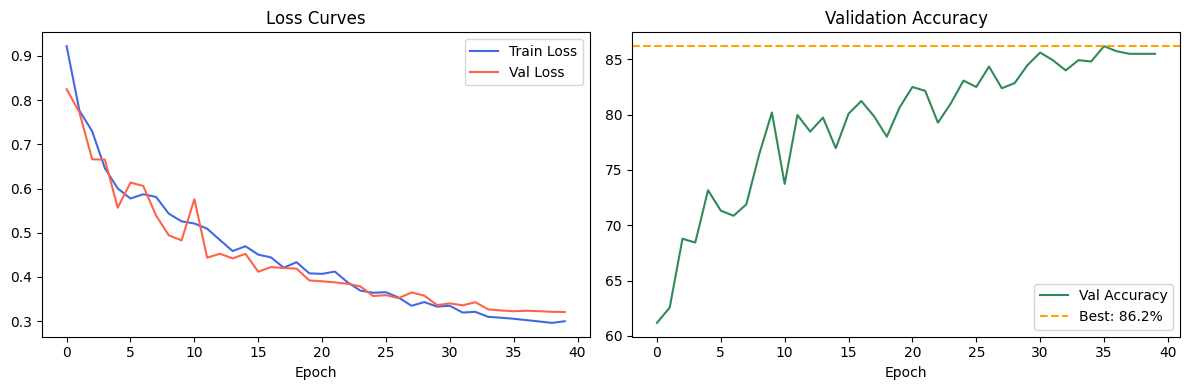

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='royalblue')
ax1.plot(val_losses,   label='Val Loss',   color='tomato')
ax1.set_title('Loss Curves');  ax1.set_xlabel('Epoch');  ax1.legend()

ax2.plot(val_accs, color='seagreen', label='Val Accuracy')
ax2.axhline(best_val_acc, color='orange', linestyle='--', label=f'Best: {best_val_acc:.1f}%')
ax2.set_title('Validation Accuracy');  ax2.set_xlabel('Epoch');  ax2.legend()

plt.tight_layout()
plt.show()

## Step 11 — Evaluate on Validation Set

Classification Report:
              precision    recall  f1-score   support

     Walking       0.96      0.85      0.90       432
    Standing       0.75      0.81      0.78       202
    Crossing       0.82      0.93      0.87       234

    accuracy                           0.86       868
   macro avg       0.84      0.86      0.85       868
weighted avg       0.87      0.86      0.86       868



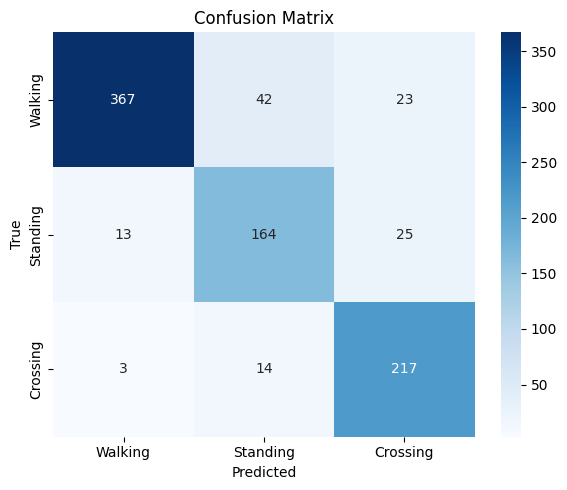

In [19]:
# Load best checkpoint
model.load_state_dict(torch.load('/tmp/best_lstm.pth', map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(DEVICE)
        preds = model(xb).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

# Only report classes that appear in validation
present = sorted(set(all_true) | set(all_preds))
present_names = [CLASS_NAMES[i] for i in present]

print('Classification Report:')
print(classification_report(all_true, all_preds, labels=present, target_names=present_names))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds, labels=present)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names)
plt.title('Confusion Matrix')
plt.ylabel('True');  plt.xlabel('Predicted')
plt.tight_layout();  plt.show()

## Step 12 — Save Final Model

In [20]:
torch.save({
    'model_state'  : model.state_dict(),
    'class_names'  : CLASS_NAMES,
    'n_features'   : N_FEATURES,
    'feat_cols'    : FEAT_COLS,
    'seq_len'      : SEQ_LEN,
    'hidden'       : 128,
    'n_layers'     : 2,
    'n_classes'    : N_CLASSES,
    'best_val_acc' : best_val_acc
}, OUTPUT_MODEL)

print(f' Model saved → {OUTPUT_MODEL}')
print(f'   Best Val Accuracy : {best_val_acc:.1f}%')
print(f'   Classes           : {CLASS_NAMES}')
print(f'   Seq len / Features: {SEQ_LEN} / {N_FEATURES}')

 Model saved → /content/drive/MyDrive/GIU.Master/lstm_action_classifier.pth
   Best Val Accuracy : 86.2%
   Classes           : ['Walking', 'Standing', 'Crossing']
   Seq len / Features: 20 / 8
